# MedFusion — Multi-Modal Fusion Strategies Across Image+Tabular and Image+Image Medical Data

**Standalone research notebook, two tracks.** Track A fuses dermoscopy images with tabular patient metadata to classify skin lesions. Track B fuses four MRI sequences to segment brain tumors. Different data types, different tasks, different architectures — but the same question asked twice: **does how you fuse two modalities matter, and does the answer generalize?**

If any of the fusion vocabulary below is unfamiliar, that is exactly what this notebook is for:

- **Multi-modal fusion** — combining two or more different types of input (e.g. an image and a table of numbers) into one model's decision, rather than using just one.
- **Early fusion** — combining the two modalities' features into a single joint representation *before* the classification head sees them.
- **Late fusion** — training (mostly) separate models per modality and combining only their final outputs.
- **Cross-attention fusion** — letting one modality's representation dynamically "look up" the parts of the other modality most relevant to it, rather than combining them with a fixed rule.
- **Modality ablation** — the experiment of removing one modality at a time to measure how much it actually contributes.
- **Segmentation** — predicting a label for every pixel of an image (here: tumor vs. not-tumor), not just one label for the whole image.
- **Dice coefficient / IoU** — the two standard metrics for how well a predicted segmentation mask overlaps a ground-truth one.

> Part of a small postdoc-application portfolio of medical-imaging repos, each built to demonstrate a genuinely different competency. This one covers **multi-modal learning** — tested twice, on two structurally different fusion problems, so the finding is about fusion architecture in general, not a quirk of one dataset.

## What this notebook does

```
TRACK A (image + tabular)                          TRACK B (image + image)
HAM10000 images + metadata                          BraTS: T1, T1ce, T2, FLAIR
        |  split by lesion_id                               |  split by patient ID
        v                                                    v
 ResNet-18 image encoder  +  tabular MLP encoder      2D U-Net (shared architecture)
        |                                                     |
        +-- image-only          +-- cross-attention    +-- fused (4-channel input)
        +-- tabular-only        +-- late fusion         +-- FLAIR-only (1-channel)
        +-- early fusion        (5 conditions)          +-- T1ce-only (1-channel)
                                                          (3 conditions)
        v                                                    v
 macro-F1 / AUROC / confusion matrix                Dice / IoU, fused vs. single-sequence
  fusion-strategy comparison (headline)               segmentation-quality comparison (headline)
```

1. Load HAM10000 (images + tabular metadata) and BraTS (four MRI sequences + tumor masks) — two independent datasets, loaded and processed in two independent sections of this notebook.
2. Track A: train five conditions that share one backbone/head initialization, differing only in *how* (or whether) image and tabular features are fused.
3. Track B: train three conditions that share one U-Net architecture, differing only in *how many* MRI sequences are stacked as input channels.
4. Compare each track's conditions on its own fixed, held-out test split, and visualize what the fusion mechanism is actually doing (Grad-CAM/attention for Track A, segmentation overlays for Track B).

The research question underneath both tracks: **when two modalities are available, how much does the fusion strategy itself matter**, measured against the same backbone, the same held-out test set, and the same evaluation protocol in each track?

## How to read this notebook

Every markdown cell in this notebook follows the same pattern: a plain-language paragraph first, explaining an idea in everyday terms, followed by a **"More precisely:"** paragraph that gives the exact mechanism, formula, or design rationale. Skip the second paragraph on a first read if you just want the shape of the pipeline; come back to it when you want to know *why* a specific choice was made.

This notebook has two tracks that share no code or state — Track A (Steps 1-12) finishes completely before Track B (Steps 13-20) begins. You can run either track on its own if you only attach one of the two datasets. A **Glossary** cell at the very end collects a one-line definition of every technical term used here, grouped by category and tagged with the step that introduced it.

## Pre-flight checklist

This notebook trains real neural networks (a 5-condition fusion grid in Track A, a 3-condition segmentation grid in Track B), so a GPU is required. Before running, on Kaggle:

- **Accelerator**: GPU T4 x1 (Settings -> Accelerator). Every batch size, epoch count, and data cap in this notebook is chosen to fit a T4's 16 GB VRAM in a single session, and is flagged explicitly wherever it's a real constraint rather than an arbitrary choice.
- **Internet**: only needed for Track A's ResNet-18 ImageNet-pretrained weights (Step 7). Track B needs no internet at all.
- **Datasets added**: `kmader/skin-cancer-mnist-ham10000` for Track A, `awsaf49/brats20-dataset-training-validation` for Track B (search Kaggle for either name). Attach both if you want to run the whole notebook top to bottom; attach just one if you only want that track.

Running locally instead: install `requirements.txt`, download both Kaggle datasets, and point `CFG_A["data_dir"]` (Step 1) and `CFG_B["data_dir"]` (Step 13) at wherever you extracted them.

In [1]:
!pip install -q nibabel rich
print("Packages installed.")

Packages installed.


---
# Track A — HAM10000: image + tabular fusion

Steps 1-12. Five conditions, one shared backbone/head initialization, scored on one fixed held-out test split. See `docs/methodology.md` for the full write-up.

## Step 1 — Configuration (Track A)

Every hyperparameter used anywhere in Track A lives in a single `CFG_A` dictionary, defined once, here, and referenced everywhere after — never hardcoded again in a later cell. `configs/fusion_resnet18_ham10000.yaml` documents the same values in the repository, for a future command-line version of this pipeline; the `CFG_A` cell below is the source of truth for this notebook.

A few values worth previewing: `conditions` is the list that drives the entire Step 10 training grid — it's a plain Python list, so adding a sixth fusion strategy later is a matter of writing one more model class and adding its name here, not restructuring the notebook. `group_column` is `lesion_id`, not image ID — see Step 4 for why that distinction matters.

In [2]:
from pathlib import Path

CFG_A = {
    "data_dir": "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
    "metadata_csv": "HAM10000_metadata.csv",
    "output_dir": "/kaggle/working/outputs",
    "seed": 42,
    "image_size": 224,
    "class_names": ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"],

    "test_frac": 0.15,
    "val_frac": 0.15,
    "group_column": "lesion_id",

    "categorical_columns": ["sex", "localization"],
    "categorical_embed_dim": 16,
    "numeric_columns": ["age"],
    "tabular_mlp_hidden": 64,
    "tabular_output_dim": 64,

    "backbone": "resnet18",
    "pretrained_imagenet_weights": "IMAGENET1K_V1",
    "image_feature_dim": 512,

    "fusion_hidden_dim": 256,
    "cross_attention_dim": 128,
    "conditions": ["image_only", "tabular_only", "early_fusion", "late_fusion", "cross_attention_fusion"],

    "batch_size": 64,
    "epochs": 10,
    "lr": 3e-4,
    "backbone_lr_mult": 0.1,
    "weight_decay": 1e-5,

    "loss": "focal",
    "focal_gamma": 2.0,

    "random_resized_crop_scale_min": 0.7,
    "rotation_degrees": 20,
    "horizontal_flip": True,
    "brightness_jitter": 0.1,
    "contrast_jitter": 0.1,

    "plot_dpi": 150,
    "gradcam_target_layer": "layer4",
}

Path(CFG_A["output_dir"], "checkpoints").mkdir(parents=True, exist_ok=True)
Path(CFG_A["output_dir"], "predictions").mkdir(parents=True, exist_ok=True)
Path(CFG_A["output_dir"], "tables").mkdir(parents=True, exist_ok=True)
Path(CFG_A["output_dir"], "plots").mkdir(parents=True, exist_ok=True)

print(f"Track A config loaded: {len(CFG_A)} keys, {len(CFG_A['conditions'])} conditions")

Track A config loaded: 34 keys, 5 conditions


## Step 2 — Verify the GPU

Everything in this notebook assumes a CUDA GPU is available. This cell fails loudly and immediately if one isn't, rather than letting training silently fall back to CPU and take hours instead of minutes.

**More precisely:** `torch.cuda.get_device_properties` reports the GPU's total VRAM, which is the hard ceiling every batch size and data cap in this notebook is chosen against (16 GB for a T4). Mixed precision (`torch.cuda.amp`) is available throughout for reducing memory pressure and increasing throughput, at the cost of a small amount of numerical precision — a standard, well-tested tradeoff at this scale of model.

In [3]:
import torch

assert torch.cuda.is_available(), "No CUDA GPU found. On Kaggle: Settings -> Accelerator -> GPU T4 x1."

device = torch.device("cuda")
props = torch.cuda.get_device_properties(device)
print(f"Device: {props.name}")
print(f"VRAM: {props.total_memory / 1e9:.1f} GB")
print(f"Compute capability: {props.major}.{props.minor}")

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)

Device: Tesla T4
VRAM: 15.6 GB
Compute capability: 7.5


## Step 3 — Dataset: HAM10000 (images + tabular metadata)

HAM10000 ships as a metadata CSV (one row per image: `lesion_id`, `image_id`, `dx` diagnosis code, `age`, `sex`, `localization`) plus the images themselves, usually split across two folders on Kaggle mirrors (`HAM10000_images_part_1/` and `HAM10000_images_part_2/`). Rather than hardcoding both folder names, the loader globs for every `.jpg` under `CFG_A["data_dir"]` once and builds an `image_id -> path` lookup — the same alias-tolerant discovery discipline `MedSSL` uses for its dataset mirror.

**More precisely — the class imbalance this notebook has to account for.** The seven `dx` codes are: `akiec` (actinic keratoses), `bcc` (basal cell carcinoma), `bkl` (benign keratosis), `df` (dermatofibroma), `mel` (melanoma), `nv` (melanocytic nevi), `vasc` (vascular lesions). `nv` alone is roughly two-thirds of the dataset; `df` and `vasc` are each under 2%. This is printed explicitly below, and is the direct reason Step 9 uses focal loss with inverse-frequency class weights rather than plain cross-entropy.

In [4]:
import pandas as pd

image_paths = {p.stem: p for p in Path(CFG_A["data_dir"]).rglob("*.jpg")}
print(f"Discovered {len(image_paths)} image files under {CFG_A['data_dir']}")

meta_path = next(Path(CFG_A["data_dir"]).rglob(CFG_A["metadata_csv"]))
metadata = pd.read_csv(meta_path)
metadata["image_path"] = metadata["image_id"].map(image_paths)
missing = metadata["image_path"].isna().sum()
if missing:
    print(f"Warning: {missing} metadata rows have no matching image file, dropping them")
metadata = metadata.dropna(subset=["image_path"]).reset_index(drop=True)

class_to_idx = {c: i for i, c in enumerate(CFG_A["class_names"])}
metadata["label"] = metadata["dx"].map(class_to_idx)

print(f"\n{len(metadata)} labeled images across {metadata['lesion_id'].nunique()} unique lesions\n")
counts = metadata["dx"].value_counts().reindex(CFG_A["class_names"])
for cls, n in counts.items():
    print(f"  {cls:>6s}: {n:5d}  ({100 * n / len(metadata):4.1f}%)")

Discovered 10015 image files under /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000

10015 labeled images across 7470 unique lesions

   akiec:   327  ( 3.3%)
     bcc:   514  ( 5.1%)
     bkl:  1099  (11.0%)
      df:   115  ( 1.1%)
     mel:  1113  (11.1%)
      nv:  6705  (66.9%)
    vasc:   142  ( 1.4%)


## Step 4 — Fixed, lesion-grouped splits

**In plain terms:** several images in HAM10000 are of the *same physical lesion*, photographed more than once. If we split by image, the same lesion could end up in both the training set and the test set — the model could partly "memorize" that lesion rather than generalize, and the test score would look better than it should.

**More precisely — grouped stratified splitting.** Every image is first collapsed to its `lesion_id`, each lesion assigned the diagnosis of its (typically single) associated class, and the *lesions* — not the images — are split into train/val/test using a stratified split on diagnosis. Every image belonging to a given lesion then inherits that lesion's split assignment, so no lesion crosses a split boundary. This is the direct analogue of Track B's patient-level split (Step 15), and a stronger leakage guarantee than `MedSSL`'s dataset affords, which has no identifier at all to group by.

In [5]:
from sklearn.model_selection import train_test_split

lesion_labels = metadata.groupby("lesion_id")["label"].first()
lesion_ids = lesion_labels.index.to_numpy()

train_lesions, temp_lesions = train_test_split(
    lesion_ids, test_size=CFG_A["test_frac"] + CFG_A["val_frac"],
    stratify=lesion_labels.values, random_state=CFG_A["seed"],
)
val_size = CFG_A["val_frac"] / (CFG_A["test_frac"] + CFG_A["val_frac"])
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=1 - val_size,
    stratify=lesion_labels.loc[temp_lesions].values, random_state=CFG_A["seed"],
)

split_of_lesion = {l: "train" for l in train_lesions}
split_of_lesion.update({l: "val" for l in val_lesions})
split_of_lesion.update({l: "test" for l in test_lesions})
metadata["split"] = metadata["lesion_id"].map(split_of_lesion)

overlap = set(train_lesions) & set(val_lesions) & set(test_lesions)
assert not overlap, "Lesion leakage across splits detected"

for split in ["train", "val", "test"]:
    n_img = (metadata["split"] == split).sum()
    n_les = metadata.loc[metadata["split"] == split, "lesion_id"].nunique()
    print(f"{split:>5s}: {n_img:5d} images, {n_les:5d} lesions")

train:  6981 images,  5229 lesions
  val:  1532 images,  1120 lesions
 test:  1502 images,  1121 lesions


## Step 5 — Tabular preprocessing and image augmentation

**Tabular preprocessing.** `age` is min-max normalized to `[0, 1]` using statistics computed on the *training split only*, to avoid leaking val/test distribution information into the features. `sex` and `localization` are mapped to integer category indices (with an explicit `"unknown"` bucket for missing values, rather than imputing a specific category) — those indices are looked up through a learned embedding table inside the tabular encoder itself (Step 7), not one-hot encoded here.

**More precisely — why embeddings, not one-hot.** `localization` has 15 distinct values; one-hot encoding would work but forces every category to be equidistant from every other by construction. A learned embedding lets the model discover, from data, that (for instance) "scalp" and "face" might behave more similarly to each other than either does to "acral" — a strictly more expressive representation for the same parameter budget, at some risk of overfitting on rare categories, which the small embedding dimension (16) is chosen to limit.

**Image augmentation, unlike `MedSSL`'s CXR pipeline.** Horizontal *and* vertical flip are both safe defaults here — dermoscopy has no anatomical laterality the way chest X-rays do. Color jitter is deliberately narrow (`brightness_jitter`/`contrast_jitter` = 0.1, vs. more aggressive naturalistic-image defaults), because lesion pigmentation is itself diagnostic signal for several of the seven classes, most notably melanoma — the same "don't distort what the label depends on" principle `MedSSL` applies to CXR crop aggressiveness, adapted to a different modality's specific diagnostic cue.

In [6]:
import numpy as np
import torchvision.transforms as T

train_age = metadata.loc[metadata["split"] == "train", "age"].dropna()
age_min, age_max = train_age.min(), train_age.max()
metadata["age_norm"] = ((metadata["age"] - age_min) / (age_max - age_min)).clip(0, 1).fillna(0.5)

metadata["sex"] = metadata["sex"].fillna("unknown")
metadata["localization"] = metadata["localization"].fillna("unknown")
sex_categories = sorted(metadata["sex"].unique())
loc_categories = sorted(metadata["localization"].unique())
sex_to_idx = {c: i for i, c in enumerate(sex_categories)}
loc_to_idx = {c: i for i, c in enumerate(loc_categories)}
metadata["sex_idx"] = metadata["sex"].map(sex_to_idx)
metadata["loc_idx"] = metadata["localization"].map(loc_to_idx)

CFG_A["n_sex_categories"] = len(sex_categories)
CFG_A["n_loc_categories"] = len(loc_categories)
print(f"sex categories ({len(sex_categories)}): {sex_categories}")
print(f"localization categories ({len(loc_categories)}): {loc_categories}")

train_transform = T.Compose([
    T.RandomResizedCrop(CFG_A["image_size"], scale=(CFG_A["random_resized_crop_scale_min"], 1.0)),
    T.RandomHorizontalFlip() if CFG_A["horizontal_flip"] else T.Lambda(lambda x: x),
    T.RandomVerticalFlip(),
    T.RandomRotation(CFG_A["rotation_degrees"]),
    T.ColorJitter(brightness=CFG_A["brightness_jitter"], contrast=CFG_A["contrast_jitter"]),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = T.Compose([
    T.Resize((CFG_A["image_size"], CFG_A["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

from torch.utils.data import Dataset, DataLoader
from PIL import Image

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        tabular = torch.tensor([row["age_norm"]], dtype=torch.float32)
        categorical = torch.tensor([row["sex_idx"], row["loc_idx"]], dtype=torch.long)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, tabular, categorical, label

train_ds = HAM10000Dataset(metadata[metadata["split"] == "train"], train_transform)
val_ds = HAM10000Dataset(metadata[metadata["split"] == "val"], eval_transform)
test_ds = HAM10000Dataset(metadata[metadata["split"] == "test"], eval_transform)

train_loader = DataLoader(train_ds, batch_size=CFG_A["batch_size"], shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG_A["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CFG_A["batch_size"], shuffle=False, num_workers=2)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

sex categories (3): ['female', 'male', 'unknown']
localization categories (15): ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
train=6981  val=1532  test=1502


## Step 6 — How multi-modal fusion works

**In plain terms:** a model that only sees images can only learn from pixels; a model that only sees the tabular metadata can only learn from age/sex/site. Fusion means giving one model access to both at once — the question this track asks is *how* best to combine them.

**More precisely — three fusion points.** Early fusion combines the two modalities' feature vectors *before* any task-specific reasoning happens — concatenate, then classify. Late fusion keeps the modalities almost entirely separate, training two near-independent models and combining only their final predictions — closer to an ensemble than a joint model. Cross-attention fusion sits in between: it keeps the modalities' features somewhat separate but lets one *query* the other, so the combination is data-dependent (which image regions matter depends on *this patient's* age/sex/site) rather than a fixed rule applied identically to every example.

**Cross-attention, worked through concretely.** Let `q` be the tabular encoder's 64-dim output, projected to a query vector. Let the image encoder's *pre-pool* spatial feature map (7x7 spatial locations x 512 channels, for a 224x224 input through ResNet-18) be projected, per spatial location, to a key `k_i` and value `v_i` (`i` = 1..49 locations). Attention weights are a softmax over scaled dot products:

```
score_i = (q . k_i) / sqrt(d)
alpha_i = softmax(score_i)   across all 49 locations
context = sum_i( alpha_i * v_i )
```

`context` is a single vector — a tabular-conditioned *summary* of the image, weighted toward whichever spatial locations the query (age/sex/site) found most relevant — concatenated with the raw tabular embedding and passed to a small classification head. `sqrt(d)` is the same scaling term from Vaswani et al. (2017)'s Transformer attention, preventing the dot products from growing large (and the softmax from saturating) as the projection dimension `d` grows.

**Kept single-head, deliberately.** Multi-head attention (several independent query/key/value projections, concatenated) is the standard extension, but it produces several attention maps per example instead of one — single-head keeps `alpha_i` directly visualizable as one 7x7 heatmap per prediction (Step 12), which is worth more for this notebook's explanatory purpose than the modest accuracy gain multi-head attention might add here.

In [7]:
import torch.nn as nn
import torchvision.models as tvm

def build_image_encoder():
    weights = tvm.ResNet18_Weights[CFG_A["pretrained_imagenet_weights"]]
    model = tvm.resnet18(weights=weights)
    feature_extractor = nn.Sequential(*list(model.children())[:-2])  # up to the last conv block, pre-pool
    pool = nn.AdaptiveAvgPool2d(1)
    return feature_extractor, pool

class TabularEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.sex_embed = nn.Embedding(cfg["n_sex_categories"], cfg["categorical_embed_dim"])
        self.loc_embed = nn.Embedding(cfg["n_loc_categories"], cfg["categorical_embed_dim"])
        in_dim = 1 + 2 * cfg["categorical_embed_dim"]  # age + sex_embed + loc_embed
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, cfg["tabular_mlp_hidden"]),
            nn.ReLU(inplace=True),
            nn.Linear(cfg["tabular_mlp_hidden"], cfg["tabular_output_dim"]),
        )

    def forward(self, numeric, categorical):
        sex_e = self.sex_embed(categorical[:, 0])
        loc_e = self.loc_embed(categorical[:, 1])
        x = torch.cat([numeric, sex_e, loc_e], dim=1)
        return self.mlp(x)

## Step 7 — Model architectures: the five conditions

Each condition below is a small `nn.Module` built from the two shared encoders (Step 6). All five initialize `build_image_encoder()` from the identical ImageNet checkpoint and `TabularEncoder` from the identical seeded random initialization (Step 8 states why this matters).

In [8]:
class ImageOnlyModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.features, self.pool = build_image_encoder()
        self.head = nn.Linear(cfg["image_feature_dim"], len(cfg["class_names"]))

    def forward(self, image, numeric, categorical):
        f = self.pool(self.features(image)).flatten(1)
        return self.head(f)

class TabularOnlyModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tabular = TabularEncoder(cfg)
        self.head = nn.Linear(cfg["tabular_output_dim"], len(cfg["class_names"]))

    def forward(self, image, numeric, categorical):
        t = self.tabular(numeric, categorical)
        return self.head(t)

class EarlyFusionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.features, self.pool = build_image_encoder()
        self.tabular = TabularEncoder(cfg)
        in_dim = cfg["image_feature_dim"] + cfg["tabular_output_dim"]
        self.head = nn.Sequential(
            nn.Linear(in_dim, cfg["fusion_hidden_dim"]),
            nn.ReLU(inplace=True),
            nn.Linear(cfg["fusion_hidden_dim"], len(cfg["class_names"])),
        )

    def forward(self, image, numeric, categorical):
        f = self.pool(self.features(image)).flatten(1)
        t = self.tabular(numeric, categorical)
        return self.head(torch.cat([f, t], dim=1))

class LateFusionModel(nn.Module):
    """Two near-independent branches; final logits combined by a learned softmax-normalized weight."""
    def __init__(self, cfg):
        super().__init__()
        self.features, self.pool = build_image_encoder()
        self.image_head = nn.Linear(cfg["image_feature_dim"], len(cfg["class_names"]))
        self.tabular = TabularEncoder(cfg)
        self.tabular_head = nn.Linear(cfg["tabular_output_dim"], len(cfg["class_names"]))
        self.branch_weight = nn.Parameter(torch.zeros(2))  # softmax([0,0]) = [0.5, 0.5] at init

    def forward(self, image, numeric, categorical):
        f = self.pool(self.features(image)).flatten(1)
        image_logits = self.image_head(f)
        t = self.tabular(numeric, categorical)
        tabular_logits = self.tabular_head(t)
        w = torch.softmax(self.branch_weight, dim=0)
        return w[0] * image_logits + w[1] * tabular_logits

class CrossAttentionFusionModel(nn.Module):
    """Tabular embedding as query, image spatial feature map as key/value (single-head)."""
    def __init__(self, cfg):
        super().__init__()
        self.features, _ = build_image_encoder()
        self.tabular = TabularEncoder(cfg)
        d = cfg["cross_attention_dim"]
        self.query_proj = nn.Linear(cfg["tabular_output_dim"], d)
        self.key_proj = nn.Linear(cfg["image_feature_dim"], d)
        self.value_proj = nn.Linear(cfg["image_feature_dim"], d)
        self.scale = d ** 0.5
        self.head = nn.Sequential(
            nn.Linear(d + cfg["tabular_output_dim"], cfg["fusion_hidden_dim"]),
            nn.ReLU(inplace=True),
            nn.Linear(cfg["fusion_hidden_dim"], len(cfg["class_names"])),
        )
        self.last_attention = None  # cached for Step 12 visualization

    def forward(self, image, numeric, categorical):
        fmap = self.features(image)  # (B, 512, 7, 7)
        B, C, H, W = fmap.shape
        fmap_flat = fmap.flatten(2).transpose(1, 2)  # (B, 49, 512)

        t = self.tabular(numeric, categorical)
        q = self.query_proj(t).unsqueeze(1)             # (B, 1, d)
        k = self.key_proj(fmap_flat)                     # (B, 49, d)
        v = self.value_proj(fmap_flat)                    # (B, 49, d)

        scores = (q @ k.transpose(1, 2)) / self.scale     # (B, 1, 49)
        alpha = torch.softmax(scores, dim=-1)
        self.last_attention = alpha.detach().reshape(B, H, W)

        context = (alpha @ v).squeeze(1)                   # (B, d)
        return self.head(torch.cat([context, t], dim=1))

MODEL_CLASSES = {
    "image_only": ImageOnlyModel,
    "tabular_only": TabularOnlyModel,
    "early_fusion": EarlyFusionModel,
    "late_fusion": LateFusionModel,
    "cross_attention_fusion": CrossAttentionFusionModel,
}
print(f"Registered {len(MODEL_CLASSES)} Track A conditions: {list(MODEL_CLASSES.keys())}")

Registered 5 Track A conditions: ['image_only', 'tabular_only', 'early_fusion', 'late_fusion', 'cross_attention_fusion']


## Step 8 — Design decision: one shared initialization, five roles

Every one of the five conditions above is built from `build_image_encoder()` (identical ImageNet-pretrained weights) and `TabularEncoder(cfg)` (identical seeded random initialization) — construction functions called fresh for each condition, never a shared in-memory object. Training hyperparameters (optimizer, learning rate schedule, loss, epoch count) are also identical across all five.

This is the direct analogue of `MedSSL`'s "one encoder checkpoint, three roles" discipline: the only thing that is allowed to differ between conditions is the fusion mechanism itself. Without this discipline, a reported gap between (say) early fusion and cross-attention fusion could just as easily be an artifact of a lucky initialization or an inconsistent training budget as a genuine architectural difference — and the whole point of Track A is to make a claim about the fusion mechanism specifically.

**A caveat worth stating explicitly.** The image-only and tabular-only baselines are *not* handicapped versions of the fusion models — they have their own dedicated head sized for their single modality, not a fusion head with one branch zeroed out. This is a deliberate choice: comparing against an artificially crippled fusion model would bias the comparison in fusion's favor before a single epoch of training runs.

## Step 9 — Loss and training loop

**In plain terms:** the model needs a number to minimize during training. Plain cross-entropy would work, but with `nv` at roughly two-thirds of the dataset (Step 3), a model that mostly ignores the rare classes and predicts `nv` by default would already score deceptively well on raw accuracy.

**More precisely — focal loss.** Cross-entropy loss for a single example is `-log(p_t)`, where `p_t` is the model's predicted probability for the *true* class. Focal loss (Lin et al., 2017) multiplies this by a modulating factor `(1 - p_t)^gamma`:

```
FL(p_t) = -(1 - p_t)^gamma * log(p_t)
```

When the model is already confident and correct (`p_t` close to 1), `(1 - p_t)^gamma` is close to 0, so well-classified examples contribute almost nothing to the loss — training focuses its gradient on examples the model is still getting wrong, which are disproportionately the rare classes once the model has learned the easy majority-class pattern. This is combined with per-class weights set by inverse training-split frequency, so both effects — down-weighting easy examples and up-weighting rare classes — compound rather than substitute for each other.

In [9]:
import torch.nn.functional as F

class_counts = metadata.loc[metadata["split"] == "train", "label"].value_counts().reindex(range(len(CFG_A["class_names"]))).fillna(0)
class_weights = (1.0 / class_counts.clip(lower=1)).to_numpy()
class_weights = class_weights / class_weights.sum() * len(CFG_A["class_names"])
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Inverse-frequency class weights:", np.round(class_weights, 2))

class FocalLoss(nn.Module):
    def __init__(self, gamma, weight):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, target):
        log_p = F.log_softmax(logits, dim=1)
        p_t = log_p.exp().gather(1, target.unsqueeze(1)).squeeze(1)
        ce = F.nll_loss(log_p, target, weight=self.weight, reduction="none")
        focal_term = (1 - p_t).clamp(min=1e-6) ** self.gamma
        return (focal_term * ce).mean()

criterion_a = FocalLoss(CFG_A["focal_gamma"], class_weights_t)

def run_epoch_track_a(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for image, numeric, categorical, label in loader:
            image, numeric, categorical, label = (
                image.to(device), numeric.to(device), categorical.to(device), label.to(device)
            )
            logits = model(image, numeric, categorical)
            loss = criterion_a(logits, label)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * image.size(0)
            all_preds.append(logits.detach().softmax(1).cpu())
            all_labels.append(label.cpu())
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return total_loss / len(loader.dataset), preds, labels

def build_optimizer_track_a(model, cfg):
    backbone_params, head_params = [], []
    for name, p in model.named_parameters():
        if "features" in name:
            backbone_params.append(p)
        else:
            head_params.append(p)
    groups = [{"params": head_params, "lr": cfg["lr"]}]
    if backbone_params:
        groups.append({"params": backbone_params, "lr": cfg["lr"] * cfg["backbone_lr_mult"]})
    return torch.optim.AdamW(groups, weight_decay=cfg["weight_decay"])

Inverse-frequency class weights: [0.92 0.57 0.26 2.88 0.26 0.04 2.06]


## Step 10 — Train all five conditions

A plain loop over `CFG_A["conditions"]`, each building a fresh model from `MODEL_CLASSES`, training for `CFG_A["epochs"]` epochs, and checkpointing the version with the best validation macro-F1 — the same "track best-val, evaluate best-val on test, never test-set-tuned" discipline used throughout this portfolio.

In [10]:
from sklearn.metrics import f1_score
import copy, time

track_a_histories = {}
track_a_best_states = {}

for condition in CFG_A["conditions"]:
    print(f"\n=== Training condition: {condition} ===")
    torch.manual_seed(CFG_A["seed"])
    model = MODEL_CLASSES[condition](CFG_A).to(device)
    optimizer = build_optimizer_track_a(model, CFG_A)

    best_val_f1, best_state = -1.0, None
    history = []
    t0 = time.time()
    for epoch in range(CFG_A["epochs"]):
        train_loss, _, _ = run_epoch_track_a(model, train_loader, optimizer)
        val_loss, val_preds, val_labels = run_epoch_track_a(model, val_loader)
        val_f1 = f1_score(val_labels, val_preds.argmax(1), average="macro")
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_f1})
        if val_f1 > best_val_f1:
            best_val_f1, best_state = val_f1, copy.deepcopy(model.state_dict())
        print(f"  epoch {epoch+1:2d}/{CFG_A['epochs']}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_macro_f1={val_f1:.4f}")

    track_a_histories[condition] = history
    track_a_best_states[condition] = best_state
    torch.save(best_state, f"{CFG_A['output_dir']}/checkpoints/track_a_{condition}.pt")
    print(f"  best val macro-F1: {best_val_f1:.4f}  ({time.time()-t0:.0f}s)")


=== Training condition: image_only ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


  epoch  1/10  train_loss=0.1865  val_loss=0.2061  val_macro_f1=0.3977
  epoch  2/10  train_loss=0.0969  val_loss=0.1759  val_macro_f1=0.5177
  epoch  3/10  train_loss=0.0745  val_loss=0.1554  val_macro_f1=0.5303
  epoch  4/10  train_loss=0.0655  val_loss=0.1555  val_macro_f1=0.5574
  epoch  5/10  train_loss=0.0541  val_loss=0.1872  val_macro_f1=0.5626
  epoch  6/10  train_loss=0.0455  val_loss=0.2123  val_macro_f1=0.5280
  epoch  7/10  train_loss=0.0409  val_loss=0.1897  val_macro_f1=0.5330
  epoch  8/10  train_loss=0.0366  val_loss=0.1985  val_macro_f1=0.5811
  epoch  9/10  train_loss=0.0340  val_loss=0.2389  val_macro_f1=0.5871
  epoch 10/10  train_loss=0.0314  val_loss=0.1863  val_macro_f1=0.6277
  best val macro-F1: 0.6277  (559s)

=== Training condition: tabular_only ===
  epoch  1/10  train_loss=0.2801  val_loss=0.2925  val_macro_f1=0.1406
  epoch  2/10  train_loss=0.2587  val_loss=0.2768  val_macro_f1=0.1851
  epoch  3/10  train_loss=0.2452  val_loss=0.2685  val_macro_f1=0.1785

## Step 11 — Track A results: the fusion-strategy comparison

Each condition's best-validation checkpoint (Step 10) is reloaded and evaluated once on the held-out test split — the same test set, untouched until now, for every condition. Macro-F1, per-class one-vs-rest AUROC, and a confusion matrix are computed per condition; the fusion-strategy comparison bar chart below is this track's headline figure.

             condition  macro_f1  macro_auroc
            image_only  0.607958     0.948585
          tabular_only  0.173345     0.683700
          early_fusion  0.641033     0.948832
           late_fusion  0.634192     0.955317
cross_attention_fusion  0.667221     0.947313


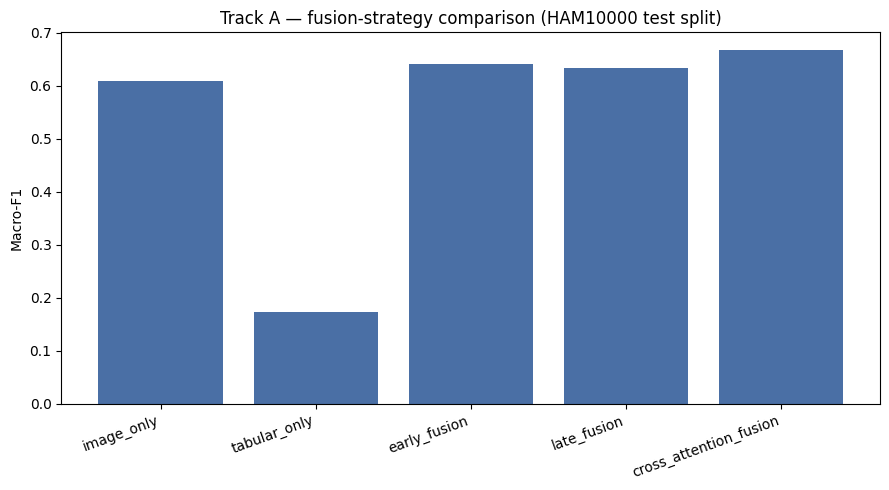

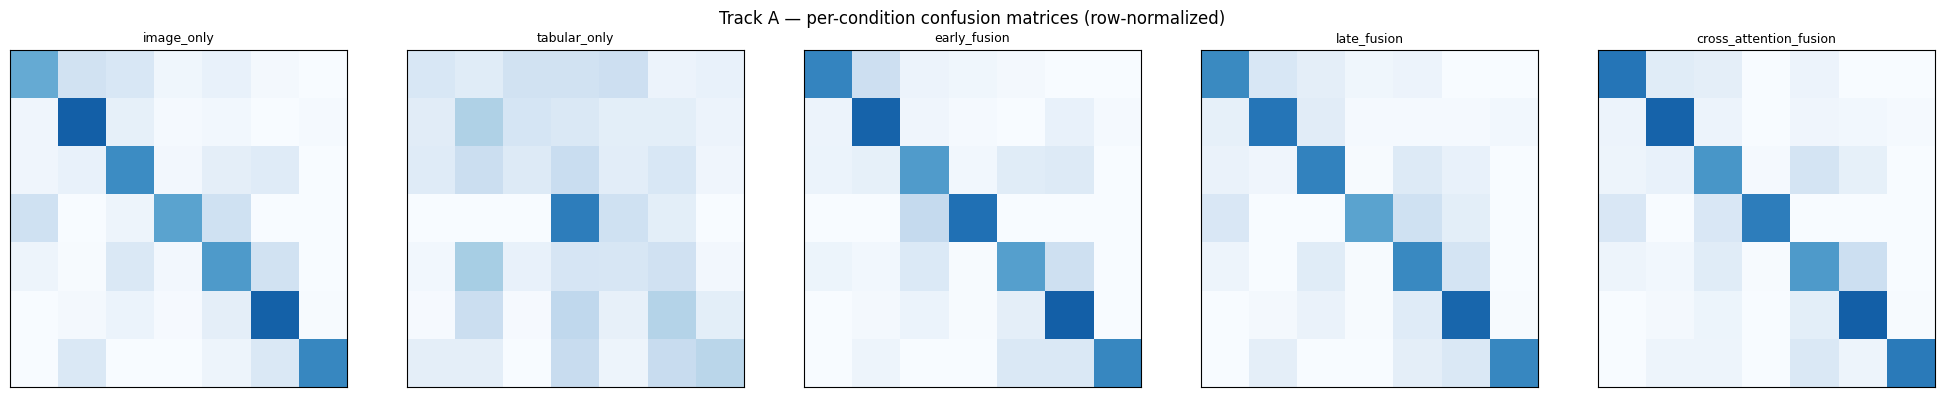

In [11]:
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

track_a_results = []
track_a_test_preds = {}

for condition in CFG_A["conditions"]:
    model = MODEL_CLASSES[condition](CFG_A).to(device)
    model.load_state_dict(track_a_best_states[condition])
    _, test_preds, test_labels = run_epoch_track_a(model, test_loader)
    track_a_test_preds[condition] = (test_preds, test_labels)

    pred_labels = test_preds.argmax(1)
    macro_f1 = f1_score(test_labels, pred_labels, average="macro")
    try:
        macro_auroc = roc_auc_score(test_labels, test_preds, multi_class="ovr", average="macro")
    except ValueError:
        macro_auroc = float("nan")  # can happen if a class is absent from a small test split
    track_a_results.append({"condition": condition, "macro_f1": macro_f1, "macro_auroc": macro_auroc})
    np.savez(f"{CFG_A['output_dir']}/predictions/track_a_{condition}.npz", preds=test_preds, labels=test_labels)

results_df = pd.DataFrame(track_a_results)
results_df.to_csv(f"{CFG_A['output_dir']}/tables/track_a_fusion_results.csv", index=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(results_df["condition"], results_df["macro_f1"], color="#4a6fa5", label="Macro-F1")
ax.set_ylabel("Macro-F1")
ax.set_title("Track A — fusion-strategy comparison (HAM10000 test split)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{CFG_A['output_dir']}/plots/track_a_fusion_comparison.png", dpi=CFG_A["plot_dpi"])
plt.show()

fig, axes = plt.subplots(1, len(CFG_A["conditions"]), figsize=(4 * len(CFG_A["conditions"]), 4))
for ax, condition in zip(axes, CFG_A["conditions"]):
    preds, labels = track_a_test_preds[condition]
    cm = confusion_matrix(labels, preds.argmax(1), normalize="true")
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(condition, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Track A — per-condition confusion matrices (row-normalized)")
plt.tight_layout()
plt.savefig(f"{CFG_A['output_dir']}/plots/track_a_confusion_matrices.png", dpi=CFG_A["plot_dpi"])
plt.show()

## Step 12 — Grad-CAM and attention: which modality drove this prediction?

**In plain terms:** a metrics table says *how well* each condition performs; it doesn't say *why*. Grad-CAM highlights which pixels of the input image most influenced a prediction; the cross-attention condition's own attention weights (Step 7) directly show which image regions the tabular metadata caused the model to focus on.

**More precisely — Grad-CAM.** For a chosen convolutional layer (`CFG_A["gradcam_target_layer"]`, ResNet-18's final block), Grad-CAM computes the gradient of the predicted class's logit with respect to that layer's activations, global-average-pools the gradient per channel to get an importance weight per channel, and produces a heatmap as the weighted sum of activation channels, ReLU'd to keep only positive (class-supporting) evidence — hand-rolled here via a forward/backward hook, the same technique `MedSSL` uses for its own Grad-CAM cell, with no extra dependency.

**Attention-weight visualization.** For the cross-attention condition specifically, `model.last_attention` (cached during the forward pass in Step 7) is a 7x7 map of `alpha_i` values — no gradient computation needed, since it's already the model's actual internal attention distribution, not an approximation of it the way Grad-CAM is.

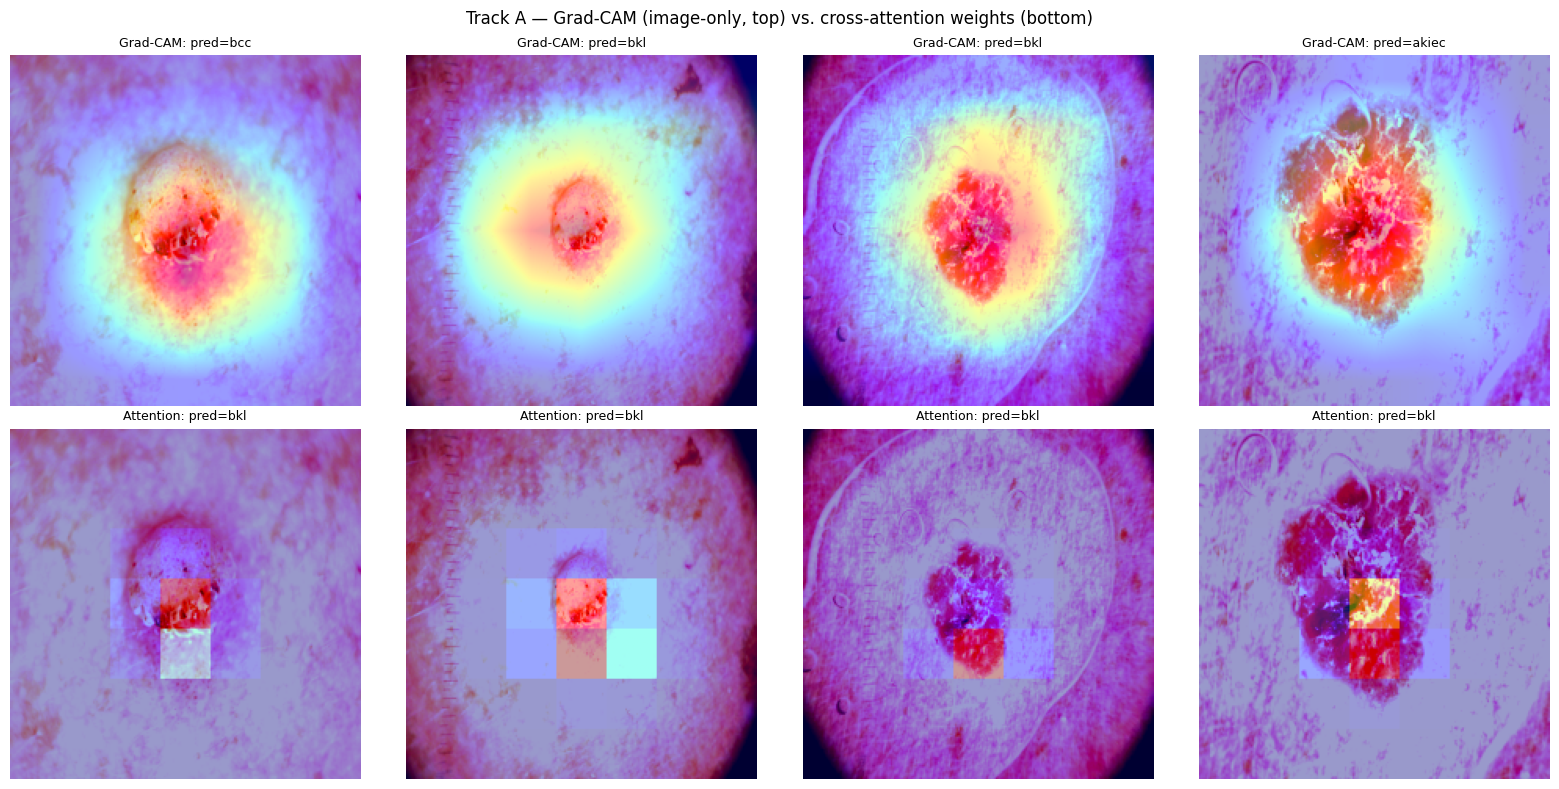

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, image, numeric, categorical, class_idx):
        logits = self.model(image, numeric, categorical)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=image.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ResNet-18's children, in order, before the last two (avgpool, fc) were dropped in
# build_image_encoder() -- this is the name -> index mapping CFG_A["gradcam_target_layer"] refers to.
RESNET18_LAYER_NAMES = ["conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4"]

def find_target_layer(model, layer_name):
    idx = RESNET18_LAYER_NAMES.index(layer_name)
    return model.features[idx]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
example_image, example_numeric, example_categorical, example_label = next(iter(test_loader))
example_image = example_image[:4].to(device)
example_numeric = example_numeric[:4].to(device)
example_categorical = example_categorical[:4].to(device)

model_ig = MODEL_CLASSES["image_only"](CFG_A).to(device)
model_ig.load_state_dict(track_a_best_states["image_only"])
model_ig.eval()
cam = GradCAM(model_ig, find_target_layer(model_ig, CFG_A["gradcam_target_layer"]))

for i in range(4):
    img = example_image[i:i+1].requires_grad_(False)
    pred_class = model_ig(img, example_numeric[i:i+1], example_categorical[i:i+1]).argmax(1).item()
    heatmap = cam(img, example_numeric[i:i+1], example_categorical[i:i+1], pred_class)
    axes[0, i].imshow(img[0].detach().cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0, i].imshow(heatmap, cmap="jet", alpha=0.4)
    axes[0, i].set_title(f"Grad-CAM: pred={CFG_A['class_names'][pred_class]}", fontsize=9)
    axes[0, i].axis("off")

model_ca = MODEL_CLASSES["cross_attention_fusion"](CFG_A).to(device)
model_ca.load_state_dict(track_a_best_states["cross_attention_fusion"])
model_ca.eval()
with torch.no_grad():
    logits = model_ca(example_image, example_numeric, example_categorical)
    pred_classes = logits.argmax(1)

for i in range(4):
    attn = model_ca.last_attention[i].cpu().numpy()
    attn_upsampled = np.kron(attn, np.ones((32, 32)))  # 7x7 -> 224x224, nearest-neighbor
    axes[1, i].imshow(example_image[i].detach().cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, i].imshow(attn_upsampled, cmap="jet", alpha=0.4)
    axes[1, i].set_title(f"Attention: pred={CFG_A['class_names'][pred_classes[i].item()]}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Track A — Grad-CAM (image-only, top) vs. cross-attention weights (bottom)")
plt.tight_layout()
plt.savefig(f"{CFG_A['output_dir']}/plots/track_a_gradcam_attention.png", dpi=CFG_A["plot_dpi"])
plt.show()

---
# Track B — BraTS: image + image fusion

Steps 13-20. Three input-channel conditions, one shared U-Net architecture, scored on one fixed patient-level held-out test split. See `docs/methodology.md` for the full write-up. Track B shares no code or state with Track A above — if you only attached the BraTS dataset, you can run this section on its own.

## Step 13 — Configuration (Track B)

Same discipline as Step 1: every Track B hyperparameter lives in `CFG_B`, mirrored in `configs/unet_brats.yaml`. Note `in_channels` is a dict keyed by condition name — the one deliberate difference between the three U-Nets trained in Step 19 is how many MRI sequences they receive as input channels.

In [13]:
CFG_B = {
    "data_dir": "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation",
    "output_dir": "/kaggle/working/outputs",
    "seed": 42,
    "sequences": ["t1", "t1ce", "t2", "flair"],
    "native_resolution": 240,
    "image_size": 128,

    "max_patients": 60,
    "slice_axis": "axial",
    "max_tumor_slices_per_patient": 8,
    "min_tumor_pixels_per_slice": 50,

    "test_frac": 0.15,
    "val_frac": 0.15,

    "n_classes": 1,

    "unet_base_channels": 32,
    "unet_depth": 4,
    "conditions": ["fused_4seq", "flair_only", "t1ce_only"],
    "in_channels": {"fused_4seq": 4, "flair_only": 1, "t1ce_only": 1},

    "batch_size": 16,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,

    "loss": "dice_bce",
    "dice_bce_weight": 0.5,
    "dice_smooth": 1.0,

    "plot_dpi": 150,
    "overlay_alpha": 0.4,
}

Path(CFG_B["output_dir"], "checkpoints").mkdir(parents=True, exist_ok=True)
Path(CFG_B["output_dir"], "predictions").mkdir(parents=True, exist_ok=True)
Path(CFG_B["output_dir"], "tables").mkdir(parents=True, exist_ok=True)
Path(CFG_B["output_dir"], "plots").mkdir(parents=True, exist_ok=True)

print(f"Track B config loaded: {len(CFG_B)} keys, {len(CFG_B['conditions'])} conditions")

Track B config loaded: 26 keys, 3 conditions


## Step 14 — Dataset: BraTS 2020 (four co-registered MRI sequences)

**Discovery, not hardcoded paths — the same discipline `MedSSL` applies to its own dataset mirror.** Kaggle mirrors of BraTS vary in folder nesting (an extra `MICCAI_BraTS2020_TrainingData/` wrapper is common). The loader globs for every directory whose name matches `BraTS20_Training_*`, and inside each, for the five expected NIfTI files (`*_t1.nii`, `*_t1ce.nii`, `*_t2.nii`, `*_flair.nii`, `*_seg.nii` — or their `.nii.gz` equivalents). Any patient folder missing one of the five is skipped and reported, rather than crashing deep into training.

**More precisely — what the four sequences actually show.** T1 gives good anatomical contrast between grey/white matter. T1ce (T1 post-gadolinium-contrast) is what radiologists rely on most for delineating the enhancing tumor, since contrast agent leaks through a disrupted blood-brain barrier. T2 shows the whole abnormal region (tumor + edema) with high signal. FLAIR suppresses the cerebrospinal-fluid signal that T2 doesn't, making the edema boundary the clearest of the four sequences. This is *why* Track B compares FLAIR-only and T1ce-only baselines specifically, rather than two arbitrary single-sequence choices: they are the two sequences a radiologist would reach for first for, respectively, edema and enhancing-tumor delineation.

In [14]:
import nibabel as nib

def discover_brats_patients(data_dir, max_patients, seed):
    all_dirs = sorted(Path(data_dir).rglob("BraTS20_Training_*"))
    patient_dirs = [d for d in all_dirs if d.is_dir()]
    print(f"Discovered {len(patient_dirs)} candidate patient folders under {data_dir}")

    complete = []
    for d in patient_dirs:
        files = {}
        ok = True
        for seq in CFG_B["sequences"] + ["seg"]:
            matches = list(d.glob(f"*_{seq}.nii*"))
            if not matches:
                ok = False
                break
            files[seq] = matches[0]
        if ok:
            complete.append({"patient_id": d.name, **files})
    print(f"{len(complete)} patients have all 4 sequences + segmentation mask")

    rng = np.random.RandomState(seed)
    if len(complete) > max_patients:
        idx = rng.choice(len(complete), size=max_patients, replace=False)
        complete = [complete[i] for i in sorted(idx)]
    print(f"Using {len(complete)} patients (capped at max_patients={max_patients}, seed={seed})")
    return complete

brats_patients = discover_brats_patients(CFG_B["data_dir"], CFG_B["max_patients"], CFG_B["seed"])

# quick sanity check: load one patient's volumes and confirm shapes agree
sample = brats_patients[0]
sample_vols = {seq: nib.load(sample[seq]).get_fdata() for seq in CFG_B["sequences"] + ["seg"]}
for seq, vol in sample_vols.items():
    print(f"  {seq:>6s}: shape={vol.shape}, dtype={vol.dtype}")

Discovered 369 candidate patient folders under /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation
368 patients have all 4 sequences + segmentation mask
Using 60 patients (capped at max_patients=60, seed=42)
      t1: shape=(240, 240, 155), dtype=float64
    t1ce: shape=(240, 240, 155), dtype=float64
      t2: shape=(240, 240, 155), dtype=float64
   flair: shape=(240, 240, 155), dtype=float64
     seg: shape=(240, 240, 155), dtype=float64


## Step 15 — Patient-level splits and axial slice extraction

**Splitting first, at the patient level.** Unlike Track A's `lesion_id` workaround or `MedSSL`'s dataset (which has no identifier at all), BraTS provides a real per-patient case folder as its natural split unit. `brats_patients` (Step 14) is split train/val/test *before* any slice is extracted, so every slice from a given patient's volume lands in exactly one split.

**More precisely — why only tumor-containing slices, and why capped.** A full 155-slice volume is mostly slices with little or no tumor (see `docs/methodology.md`, Data). Sampling *every* slice would (a) make the dataset overwhelmingly background-only, which both destabilizes Dice-loss training and makes Dice/IoU evaluation degenerate on empty-mask slices, and (b) blow well past a single Kaggle session's runtime budget once repeated for three conditions. The loader therefore keeps only slices with at least `min_tumor_pixels_per_slice` foreground pixels, and caps the count kept per patient at `max_tumor_slices_per_patient` — evenly spaced through the patient's tumor-containing range, not just the first N, so a given patient contributes slices spanning the tumor's extent rather than a redundant cluster.

In [15]:
def extract_tumor_slices(patient, cfg):
    seg = nib.load(patient["seg"]).get_fdata()
    tumor_mask = seg > 0
    axial_tumor_pixel_counts = tumor_mask.sum(axis=(0, 1))
    candidate_slices = np.where(axial_tumor_pixel_counts >= cfg["min_tumor_pixels_per_slice"])[0]
    if len(candidate_slices) == 0:
        return []
    if len(candidate_slices) > cfg["max_tumor_slices_per_patient"]:
        idx = np.linspace(0, len(candidate_slices) - 1, cfg["max_tumor_slices_per_patient"]).astype(int)
        candidate_slices = candidate_slices[idx]
    return [{"patient_id": patient["patient_id"], "patient": patient, "slice_idx": int(s)} for s in candidate_slices]

train_patients, temp_patients = train_test_split(brats_patients, test_size=CFG_B["test_frac"] + CFG_B["val_frac"], random_state=CFG_B["seed"])
val_size_b = CFG_B["val_frac"] / (CFG_B["test_frac"] + CFG_B["val_frac"])
val_patients, test_patients = train_test_split(temp_patients, test_size=1 - val_size_b, random_state=CFG_B["seed"])

brats_splits = {}
for split_name, patients in [("train", train_patients), ("val", val_patients), ("test", test_patients)]:
    slices = []
    for p in patients:
        slices.extend(extract_tumor_slices(p, CFG_B))
    brats_splits[split_name] = slices
    print(f"{split_name:>5s}: {len(patients):3d} patients -> {len(slices):4d} tumor-containing slices")

train_patient_ids = {p["patient_id"] for p in train_patients}
test_patient_ids = {p["patient_id"] for p in test_patients}
assert not (train_patient_ids & test_patient_ids), "Patient leakage between train and test detected"

train:  42 patients ->  336 tumor-containing slices
  val:   9 patients ->   72 tumor-containing slices
 test:   9 patients ->   72 tumor-containing slices


## Step 16 — How 2D U-Net segmentation works

**In plain terms:** classification asks "what is this image?"; segmentation asks "which pixels belong to the thing I care about?" A U-Net answers this by first shrinking the image through a series of convolutions (learning *what* is in it, losing precise *where*), then growing it back to full resolution (recovering precise *where*), while directly copying detail from the shrinking path across to the growing path so fine spatial detail lost to pooling isn't lost forever.

**More precisely — the encoder-decoder-with-skip-connections architecture.** The **encoder** (downsampling path) applies repeated `[Conv -> BatchNorm -> ReLU] x2 -> MaxPool` blocks, doubling the channel count and halving the spatial resolution at each stage — structurally the same pattern as a classification CNN's backbone, in fact building the same kind of "what is in this image" feature hierarchy. The **decoder** (upsampling path) reverses this: each stage upsamples (`ConvTranspose2d`), then **concatenates** the result with the encoder stage of matching resolution (the "skip connection") before another `[Conv -> BatchNorm -> ReLU] x2` block. The skip connection is the architectural idea that makes U-Net a *segmentation* network rather than just an autoencoder: without it, the decoder would have to reconstruct fine boundary detail purely from the deeply-compressed bottleneck representation, which discards exactly the pixel-precise spatial information segmentation needs.

**Dice loss, worked through on a toy example.** For a predicted probability mask `P` and ground-truth binary mask `G`, the Dice coefficient is:

```
Dice(P, G) = 2 * sum(P * G) / (sum(P) + sum(G))
```

Suppose a 2x2 patch has ground truth `G = [1,1,0,0]` and the model predicts `P = [0.9,0.8,0.1,0.3]`. Then `sum(P*G) = 0.9+0.8 = 1.7`, `sum(P) = 2.1`, `sum(G) = 2`, giving `Dice = 2*1.7 / (2.1+2) = 0.829` — close to 1 (good overlap) because the model assigned high probability where the true mask is 1 and low probability where it's 0. The loss used in training is `1 - Dice`, with a small smoothing constant (`dice_smooth = 1.0`) added to numerator and denominator to avoid division-by-zero on an entirely-empty ground-truth mask.

In [16]:
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight, smooth):
        super().__init__()
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, target):
        bce_loss = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        intersection = (probs * target).sum(dim=(1, 2, 3))
        dice = (2 * intersection + self.smooth) / (probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + self.smooth)
        dice_loss = 1 - dice.mean()
        return self.dice_weight * dice_loss + (1 - self.dice_weight) * bce_loss

criterion_b = DiceBCELoss(CFG_B["dice_bce_weight"], CFG_B["dice_smooth"])

## Step 17 — Building the 2D U-Net

A small, config-driven U-Net implementing exactly the encoder-decoder-with-skip-connections structure described in Step 16. `in_channels` is the one architectural parameter that changes across Track B's three conditions (Step 18); everything else — depth, base channel width, number of parameters in every other layer — is identical.

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_channels, out_channels, base_channels, depth):
        super().__init__()
        chs = [base_channels * (2 ** i) for i in range(depth + 1)]  # e.g. [32,64,128,256,512]

        self.encoder_blocks = nn.ModuleList()
        prev_ch = in_channels
        for ch in chs[:-1]:
            self.encoder_blocks.append(ConvBlock(prev_ch, ch))
            prev_ch = ch
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(chs[-2], chs[-1])

        self.upconvs = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        prev_ch = chs[-1]
        for ch in reversed(chs[:-1]):
            self.upconvs.append(nn.ConvTranspose2d(prev_ch, ch, kernel_size=2, stride=2))
            self.decoder_blocks.append(ConvBlock(ch * 2, ch))  # *2: concatenated with skip connection
            prev_ch = ch

        self.out_conv = nn.Conv2d(chs[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for block in self.encoder_blocks:
            x = block(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for upconv, block, skip in zip(self.upconvs, self.decoder_blocks, reversed(skips)):
            x = upconv(x)
            x = torch.cat([x, skip], dim=1)
            x = block(x)

        return self.out_conv(x)

def build_unet(condition, cfg):
    return UNet2D(
        in_channels=cfg["in_channels"][condition],
        out_channels=cfg["n_classes"],
        base_channels=cfg["unet_base_channels"],
        depth=cfg["unet_depth"],
    )

test_unet = build_unet("fused_4seq", CFG_B)
n_params = sum(p.numel() for p in test_unet.parameters())
print(f"UNet2D (fused_4seq, in_channels=4): {n_params/1e6:.2f}M parameters")
del test_unet

UNet2D (fused_4seq, in_channels=4): 7.77M parameters


## Step 18 — Design decision: shared architecture, one input-channel difference

All three Track B conditions call `build_unet(condition, CFG_B)`, which differs between calls in exactly one argument: `in_channels`. Depth, base channel width, every convolution's kernel size, the optimizer, the loss, the learning rate, and the epoch budget are identical across `fused_4seq`, `flair_only`, and `t1ce_only`. This mirrors Track A's Step 8 discipline and `MedSSL`'s shared-classification-head design: the reported Dice/IoU gap between fused and single-sequence conditions is attributable to how many MRI sequences the model can see, not to a confound in model capacity or training budget.

**A consequence worth naming.** Because only `in_channels` changes, the fused model's very first convolution has more weights than either single-sequence model's (4 input channels vs. 1, at the same output width) — a small, unavoidable parameter-count difference that is a direct, mechanical consequence of consuming more input channels, not an independent capacity advantage layered on top of the fusion comparison.

## Step 19 — Train all three conditions

Same discipline as Step 10: loop over `CFG_B["conditions"]`, build a fresh `UNet2D` per condition, train for `CFG_B["epochs"]` epochs, checkpoint the best-validation-Dice version.

In [18]:
from torch.utils.data import Dataset as TorchDataset

def load_slice_stack(item, sequences, image_size):
    patient = item["patient"]
    slice_idx = item["slice_idx"]
    channels = []
    for seq in sequences:
        vol = nib.load(patient[seq]).get_fdata()
        sl = vol[:, :, slice_idx].astype(np.float32)
        p1, p99 = np.percentile(sl, [1, 99])
        sl = np.clip((sl - p1) / (p99 - p1 + 1e-8), 0, 1).astype(np.float32)
        channels.append(sl)
    stacked = np.stack(channels, axis=0)  # (C, H, W)
    seg_vol = nib.load(patient["seg"]).get_fdata()
    mask = (seg_vol[:, :, slice_idx] > 0).astype(np.float32)[None, :, :]  # (1, H, W)
    return stacked, mask

class BraTSSliceDataset(TorchDataset):
    def __init__(self, items, sequences, image_size):
        self.items = items
        self.sequences = sequences
        self.image_size = image_size

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        stacked, mask = load_slice_stack(self.items[idx], self.sequences, self.image_size)
        stacked_t = F.interpolate(torch.from_numpy(stacked).unsqueeze(0), size=(self.image_size, self.image_size), mode="bilinear", align_corners=False).squeeze(0)
        mask_t = F.interpolate(torch.from_numpy(mask).unsqueeze(0), size=(self.image_size, self.image_size), mode="nearest").squeeze(0)
        return stacked_t, mask_t

SEQUENCE_SUBSETS = {"fused_4seq": CFG_B["sequences"], "flair_only": ["flair"], "t1ce_only": ["t1ce"]}

def dice_score(probs, target, smooth=1.0):
    intersection = (probs * target).sum(dim=(1, 2, 3))
    return ((2 * intersection + smooth) / (probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth)).mean().item()

def iou_score(probs, target, smooth=1.0, threshold=0.5):
    pred_mask = (probs > threshold).float()
    intersection = (pred_mask * target).sum(dim=(1, 2, 3))
    union = ((pred_mask + target) > 0).float().sum(dim=(1, 2, 3))
    return ((intersection + smooth) / (union + smooth)).mean().item()

def run_epoch_track_b(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_dice, n_batches = 0.0, 0.0, 0
    with torch.set_grad_enabled(is_train):
        for stacked, mask in loader:
            stacked, mask = stacked.to(device), mask.to(device)
            logits = model(stacked)
            loss = criterion_b(logits, mask)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(torch.sigmoid(logits).detach(), mask)
            n_batches += 1
    return total_loss / n_batches, total_dice / n_batches

track_b_histories = {}
track_b_best_states = {}

for condition in CFG_B["conditions"]:
    print(f"\n=== Training condition: {condition} ===")
    sequences = SEQUENCE_SUBSETS[condition]
    train_loader_b = DataLoader(BraTSSliceDataset(brats_splits["train"], sequences, CFG_B["image_size"]), batch_size=CFG_B["batch_size"], shuffle=True, num_workers=2, drop_last=True)
    val_loader_b = DataLoader(BraTSSliceDataset(brats_splits["val"], sequences, CFG_B["image_size"]), batch_size=CFG_B["batch_size"], shuffle=False, num_workers=2)

    torch.manual_seed(CFG_B["seed"])
    model = build_unet(condition, CFG_B).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG_B["lr"], weight_decay=CFG_B["weight_decay"])

    best_val_dice, best_state = -1.0, None
    history = []
    t0 = time.time()
    for epoch in range(CFG_B["epochs"]):
        train_loss, train_dice = run_epoch_track_b(model, train_loader_b, optimizer)
        val_loss, val_dice = run_epoch_track_b(model, val_loader_b)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_dice": val_dice})
        if val_dice > best_val_dice:
            best_val_dice, best_state = val_dice, copy.deepcopy(model.state_dict())
        print(f"  epoch {epoch+1:2d}/{CFG_B['epochs']}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_dice={val_dice:.4f}")

    track_b_histories[condition] = history
    track_b_best_states[condition] = best_state
    torch.save(best_state, f"{CFG_B['output_dir']}/checkpoints/track_b_{condition}.pt")
    print(f"  best val Dice: {best_val_dice:.4f}  ({time.time()-t0:.0f}s)")


=== Training condition: fused_4seq ===
  epoch  1/20  train_loss=0.7548  val_loss=0.7958  val_dice=0.0859
  epoch  2/20  train_loss=0.6679  val_loss=0.6197  val_dice=0.1157
  epoch  3/20  train_loss=0.6270  val_loss=0.4975  val_dice=0.1903
  epoch  4/20  train_loss=0.5875  val_loss=0.6060  val_dice=0.1364
  epoch  5/20  train_loss=0.5508  val_loss=0.5648  val_dice=0.1268
  epoch  6/20  train_loss=0.5156  val_loss=0.4806  val_dice=0.2120
  epoch  7/20  train_loss=0.4841  val_loss=0.4841  val_dice=0.1987
  epoch  8/20  train_loss=0.4536  val_loss=0.4502  val_dice=0.2274
  epoch  9/20  train_loss=0.4221  val_loss=0.4367  val_dice=0.2722
  epoch 10/20  train_loss=0.3946  val_loss=0.3734  val_dice=0.3303
  epoch 11/20  train_loss=0.3695  val_loss=0.3456  val_dice=0.4039
  epoch 12/20  train_loss=0.3412  val_loss=0.3178  val_dice=0.4146
  epoch 13/20  train_loss=0.3237  val_loss=0.3428  val_dice=0.4170
  epoch 14/20  train_loss=0.2978  val_loss=0.3713  val_dice=0.4214
  epoch 15/20  train_l

## Step 20 — Track B results: the fused-vs-single-sequence gap

Each condition's best-validation checkpoint is reloaded and evaluated once on the held-out, patient-level test split's tumor-containing slices. The **fused-vs-single-sequence Dice gap is this track's headline number** — reported explicitly, not left for the reader to compute from a bar chart.

 condition  mean_dice  mean_iou
fused_4seq   0.504339  0.475616
flair_only   0.573990  0.508426
 t1ce_only   0.329771  0.279143
Headline: fused Dice (0.5043) vs. flair_only (0.5740)  ->  gap = -0.0697
Headline: fused Dice (0.5043) vs. t1ce_only (0.3298)  ->  gap = +0.1746


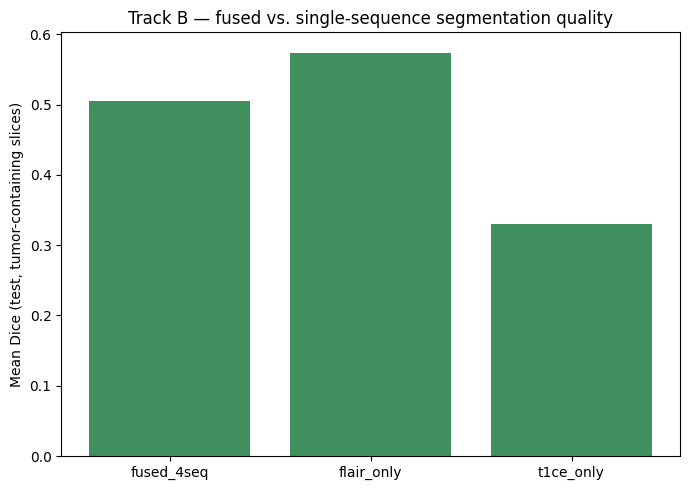

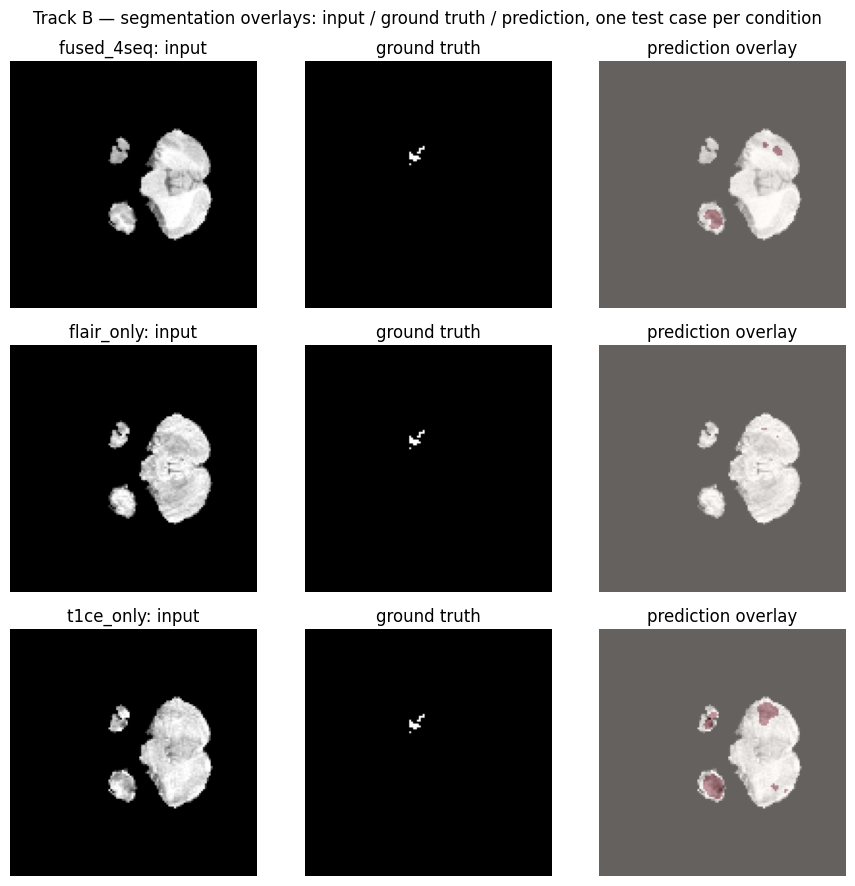

In [19]:
track_b_results = []
track_b_test_examples = {}

for condition in CFG_B["conditions"]:
    sequences = SEQUENCE_SUBSETS[condition]
    test_loader_b = DataLoader(BraTSSliceDataset(brats_splits["test"], sequences, CFG_B["image_size"]), batch_size=CFG_B["batch_size"], shuffle=False, num_workers=2)

    model = build_unet(condition, CFG_B).to(device)
    model.load_state_dict(track_b_best_states[condition])
    model.eval()

    all_dice, all_iou = [], []
    examples = []
    with torch.no_grad():
        for stacked, mask in test_loader_b:
            stacked, mask = stacked.to(device), mask.to(device)
            probs = torch.sigmoid(model(stacked))
            all_dice.append(dice_score(probs, mask))
            all_iou.append(iou_score(probs, mask))
            if len(examples) < 3:
                examples.append((stacked[0].cpu(), mask[0].cpu(), probs[0].cpu()))
    track_b_test_examples[condition] = examples

    mean_dice, mean_iou = float(np.mean(all_dice)), float(np.mean(all_iou))
    track_b_results.append({"condition": condition, "mean_dice": mean_dice, "mean_iou": mean_iou})

results_df_b = pd.DataFrame(track_b_results)
results_df_b.to_csv(f"{CFG_B['output_dir']}/tables/track_b_segmentation_results.csv", index=False)
print(results_df_b.to_string(index=False))

fused_dice = results_df_b.loc[results_df_b["condition"] == "fused_4seq", "mean_dice"].item()
for _, row in results_df_b.iterrows():
    if row["condition"] != "fused_4seq":
        gap = fused_dice - row["mean_dice"]
        print(f"Headline: fused Dice ({fused_dice:.4f}) vs. {row['condition']} ({row['mean_dice']:.4f})  ->  gap = {gap:+.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(results_df_b["condition"], results_df_b["mean_dice"], color="#3f8f5f")
ax.set_ylabel("Mean Dice (test, tumor-containing slices)")
ax.set_title("Track B — fused vs. single-sequence segmentation quality")
plt.tight_layout()
plt.savefig(f"{CFG_B['output_dir']}/plots/track_b_dice_comparison.png", dpi=CFG_B["plot_dpi"])
plt.show()

fig, axes = plt.subplots(len(CFG_B["conditions"]), 3, figsize=(9, 3 * len(CFG_B["conditions"])))
for row_i, condition in enumerate(CFG_B["conditions"]):
    stacked, mask, probs = track_b_test_examples[condition][0]
    base_img = stacked[0].numpy()  # first channel of whichever sequence(s) this condition uses
    axes[row_i, 0].imshow(base_img, cmap="gray"); axes[row_i, 0].set_title(f"{condition}: input"); axes[row_i, 0].axis("off")
    axes[row_i, 1].imshow(mask[0].numpy(), cmap="gray"); axes[row_i, 1].set_title("ground truth"); axes[row_i, 1].axis("off")
    axes[row_i, 2].imshow(base_img, cmap="gray")
    axes[row_i, 2].imshow(probs[0].numpy() > 0.5, cmap="Reds", alpha=CFG_B["overlay_alpha"])
    axes[row_i, 2].set_title("prediction overlay"); axes[row_i, 2].axis("off")
plt.suptitle("Track B — segmentation overlays: input / ground truth / prediction, one test case per condition")
plt.tight_layout()
plt.savefig(f"{CFG_B['output_dir']}/plots/track_b_segmentation_overlays.png", dpi=CFG_B["plot_dpi"])
plt.show()

## Summary

**Fill in after running:**
- Track A macro-F1 (test): image-only `___` / tabular-only `___` / early fusion `___` / late fusion `___` / cross-attention fusion `___`
- Track A macro AUROC (test): image-only `___` / tabular-only `___` / early fusion `___` / late fusion `___` / cross-attention fusion `___`
- Track B mean Dice (test): fused `___` / FLAIR-only `___` / T1ce-only `___`
- Track B headline gap (fused Dice minus best single-sequence Dice): `___`

No numbers are fabricated here — these blanks stay blank until an actual run of this notebook fills them in, and `outputs/tables/track_a_fusion_results.csv` / `outputs/tables/track_b_segmentation_results.csv` are the source of truth once it has.

### What this notebook demonstrates

- **Multi-modal fusion, tested twice.** Early / late / cross-attention fusion compared on image+tabular data (Track A); channel-stacking fusion compared against single-sequence baselines on image+image data (Track B) — two structurally different fusion problems, not two variations on one theme.
- **Modality ablation as the core experiment**, in both tracks: every fusion condition is compared against genuine single-modality baselines built from the same shared components, not against a strawman.
- **A controlled-comparison discipline** carried through both tracks and matching the rest of this portfolio: shared backbone/head initialization (Track A), shared architecture differing only in input channels (Track B), and — in both tracks — a real, non-proxy grouping unit (lesion, patient) enforced at split time to prevent leakage.

### References

- Vaswani, A., et al. (2017). *Attention Is All You Need*. arXiv:1706.03762
- Ronneberger, O., Fischer, P., Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. arXiv:1505.04597
- Lin, T.-Y., Goyal, P., Girshick, R., He, K., Dollar, P. (2017). *Focal Loss for Dense Object Detection*. arXiv:1708.02002

Full reference list, including HAM10000/BraTS-specific prior art (Yap et al., HeMIS, No New-Net), in `docs/methodology.md` and the README.

### Roadmap

This notebook is v1.0 of the pipeline described in the README's Roadmap section — see there for what's deliberately deferred to v1.1 (multi-class BraTS segmentation, multi-head cross-attention, a MIMIC-CXR+MIMIC-IV image+tabular track) and v2.0 (full 3D U-Net segmentation, nnU-Net comparison, Docker/CI).

See the Glossary below for a one-line definition of every technical term used in this notebook.

## Glossary

One-line definitions of every technical term used in this notebook, grouped by category. See the step referenced for the full explanation.

**Modeling basics**
- **Encoder** - the part of a model that turns raw input (an image, a table row) into a fixed-length feature vector. (Steps 6, 7)
- **Backbone** - the main feature-extracting network (here, ResNet-18 or the U-Net encoder path) before any task-specific head. (Steps 7, 17)
- **Head** - the final, task-specific layer(s) that turn features into a prediction. (Step 7)
- **Checkpoint** - a saved snapshot of a model's trained weights. (Step 10)
- **Epoch / batch** - one full pass over the training data / one chunk of it processed at a time. (Step 10)
- **Backbone learning-rate multiplier** - training a pretrained backbone at a lower learning rate than a freshly-initialized head, so it adapts more slowly. (Step 9)

**Multi-modal fusion (Track A)**
- **Multi-modal fusion** - combining two or more different input types into one model's decision. (Step 6)
- **Early fusion** - concatenating both modalities' features before the classification head. (Step 6)
- **Late fusion** - combining two near-independent models' final outputs rather than their features. (Step 6)
- **Cross-attention fusion** - letting one modality's representation dynamically attend over the other's, rather than combining them with a fixed rule. (Step 6)
- **Query / key / value** - the three projections attention computes: what am I looking for (query), what does each candidate offer (key), and what does each candidate actually contribute if selected (value). (Step 6)
- **Modality ablation** - removing one modality at a time to measure its individual contribution. (Step 8)
- **Focal loss** - a loss function that down-weights already-well-classified examples, focusing training on hard/rare examples. (Step 9)
- **Grad-CAM** - a technique that highlights which image regions most influenced a model's prediction. (Step 12)

**Tabular data (Track A)**
- **Categorical embedding** - a learned lookup table mapping a discrete category (e.g. lesion site) to a dense vector. (Step 5)
- **Lesion-grouped split** - a train/val/test split that keeps every image of the same lesion in one split, preventing leakage. (Step 4)

**Segmentation (Track B)**
- **Segmentation** - predicting a label for every pixel, rather than one label for the whole image. (Step 16)
- **U-Net** - an encoder-decoder segmentation architecture with skip connections between matching-resolution stages. (Step 16)
- **Skip connection** - a direct link from an encoder stage to its matching decoder stage, preserving fine spatial detail lost to pooling. (Step 16)
- **Dice coefficient / Dice loss** - an overlap metric (and its corresponding loss, `1 - Dice`) between a predicted and ground-truth mask. (Step 16)
- **IoU (Intersection over Union)** - a stricter overlap metric than Dice, computed as intersection divided by union. (Step 20)
- **Co-registration** - aligning multiple scans (here, 4 MRI sequences) to the same spatial coordinate system, so the same pixel location means the same anatomical location across sequences. (Step 14)
- **Patient-level split** - a train/val/test split performed on whole patients, so no single patient's data crosses a split boundary. (Step 15)

**Hardware**
- **VRAM** - the memory available on a GPU, the hard limit on batch size and model size. (Step 2)
- **Mixed precision (AMP)** - training with a mix of 16- and 32-bit floating point numbers to reduce memory use and increase speed. (Step 2)